In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm

import torch
import dnnlib.util_v4 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import pickle, types
from torch_utils import persistence

from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural import *
from plot_sim_results_v6 import *
from plot_sim_results_img_v6 import * 


import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

# 0. Some functions...

In [13]:
def latent_mu(latent_traj_list, encoder, dim_preserve, device, fullRes=False,
              min_var=None, rcond=None, resid_tol=1e-5, use_fp64=True):
    """
    X ≈ (L sqrt(D)) μ  ⇒  μ = D^{-1/2} L^{-1} X  (triangular) with robust fallback.
    - min_var: if None, set adaptively = max(1e-12, 1e-6 * median(D))
    - rcond:   if None, set adaptively = 1e-6 for pinv cutoff
    - resid_tol: relative residual threshold to trigger pinv path
    """
    import torch
    enc = encoder.to(device).eval()
    mu_traj, loading = [], None
    with torch.inference_mode():
        X0 = torch.from_numpy(latent_traj_list[0]).to(device=device, dtype=torch.float32)
        _, D, L = enc.encode(X0)

        d_vec = torch.diagonal(D) if D.ndim == 2 else D
        # --- adaptive thresholds ---
        mv = (max(1e-12, 1e-6 * torch.median(d_vec).item()) if min_var is None else float(min_var))
        rc = (1e-6 if rcond is None else float(rcond))

        # safe inverse sqrt
        d_safe = torch.clamp(d_vec, min=mv)
        inv_sqrt_d = d_safe.rsqrt()

        def solve_mu_batch(X):
            XT = X.T
            # optional FP64 for the solve
            if use_fp64:
                XT = XT.double(); Ld = L.double(); invsd = inv_sqrt_d.double()
            else:
                Ld = L; invsd = inv_sqrt_d
            Y = torch.linalg.solve_triangular(Ld, XT, upper=False, unitriangular=True)
            MUt = invsd.unsqueeze(1) * Y
            return MUt.T.float()  # back to fp32

        # try triangular first + residual check
        bad = False
        for arr in latent_traj_list:
            X = torch.from_numpy(arr).to(device=device, dtype=torch.float32)
            mu_full = solve_mu_batch(X)
            # residual r = ||L sqrt(D) μ - X|| / ||X||
            X_hat = (L @ torch.diag(d_safe.sqrt()) @ mu_full.T).T
            r = (X_hat - X).norm() / (X.norm() + 1e-12)
            if torch.isnan(mu_full).any() or torch.isinf(mu_full).any() or r > resid_tol:
                bad = True; break
            mu_traj.append(mu_full[:, :dim_preserve].cpu())

        # fallback: pseudoinverse with rcond
        if bad:
            loading = L @ torch.diag(d_safe.sqrt())
            if use_fp64: loading = loading.double()
            W = torch.linalg.pinv(loading, rcond=rc).float()
            mu_traj = []
            for arr in latent_traj_list:
                X = torch.from_numpy(arr).to(device=device, dtype=torch.float32)
                mu_full = (W @ X.T).T
                mu_traj.append(mu_full[:, :dim_preserve].cpu())

    if fullRes:
        return mu_traj, d_vec, L, (loading if loading is not None else L @ torch.diag(d_vec.sqrt()))
    return mu_traj

In [14]:
def hist_density_heatmap(data, bins=64, value_range=None, dims=None, density=True, log=False, per_dim_norm=False):
    X = data.reshape(len(data), -1) if data.ndim == 3 else data          # (N,784)
    if dims is None: dims = np.arange(X.shape[1])
    X = X[:, dims]
    # robust common range across dims
    if value_range is None:
        vmin, vmax = np.percentile(X, 1.0), np.percentile(X, 99.0)
    else:
        vmin, vmax = value_range
    edges = np.linspace(vmin, vmax, bins + 1)
    H = np.empty((bins, X.shape[1]), float)                                # rows: bins (low→high), cols: dims
    for j in range(X.shape[1]):
        h, _ = np.histogram(X[:, j], bins=edges, density=density)
        H[:, j] = h
    if per_dim_norm:                                                       # optional: normalize each column to [0,1]
        colmax = np.maximum(H.max(0, keepdims=True), 1e-12)
        H = H / colmax
    extent = [0, X.shape[1], edges[0], edges[-1]]
    plt.figure(figsize=(10, 4))
    im = plt.imshow(H, aspect='auto', origin='lower', extent=extent,
                    norm=LogNorm(vmin=H[H>0].min(), vmax=H.max()) if log else None)
    plt.xlabel('dimension index'); plt.ylabel('value'); plt.colorbar(im, label='hist density')
    plt.tight_layout(); 
#     plt.show()

In [15]:
def plot_ball_coordinate(trial_idx, dset_samples, T):
    x2 = dset_samples[trial_idx][0:T,:,:,:].squeeze(1)
    T, H, W = x2.shape
    flat = x2.reshape(T, -1).argmax(axis=1) # [T]
    coords = np.stack([flat // W, flat % W], axis=1)
    center = np.mean(coords, axis= 0)

    T = coords.shape[0]
    t = np.arange(T)

    shrink_end = 0.30                                  # 30% toward center by the last frame
    shrink = np.linspace(0.0, shrink_end, T)[:, None]
    xy = coords.astype(float) * (1.0 - shrink) + center * shrink

    plt.plot(xy[:,1], xy[:,0], linewidth=1.0, alpha=0.35)
    sc = plt.scatter(xy[:,1], xy[:,0], c=t, s=10, cmap='viridis_r')
    plt.colorbar(sc, label='time index')

    H2 = int(coords[:,0].max() + 1); W2 = int(coords[:,1].max() + 1)
    plt.xlim(-0.5, W2 - 0.5); plt.ylim(-0.5, H2 - 0.5)
    plt.gca().invert_yaxis()                            # match imshow's default origin='upper'
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title('trial ' + str(trial_idx))
    plt.tight_layout()

In [16]:
def plot_latent_coordinate(coords, title = None, shrink_end = 0.3):
    center = np.mean(coords, axis= 0)

    T = coords.shape[0]
    t = np.arange(T)
    
    shrink = np.linspace(0.0, shrink_end, T)[:, None]
    xy = coords.astype(float) * (1.0 - shrink) + center * shrink

    plt.plot(xy[:,1], xy[:,0], linewidth=1.0, alpha=0.35)
    sc = plt.scatter(xy[:,1], xy[:,0], c=t, s=10, cmap='viridis_r')
    plt.colorbar(sc, label='time index')

#     H2 = int(coords[:,0].max() + 1); W2 = int(coords[:,1].max() + 1)
#     plt.xlim(-0.5, W2 - 0.5); plt.ylim(-0.5, H2 - 0.5)
    plt.gca().invert_yaxis()                            # match imshow's default origin='upper'
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.tight_layout()

In [17]:
def read_model(folder, chk_pts):
    pkl_path = folder + chk_pts
    if not hasattr(persistence, "_orig_reconstruct"):
        persistence._orig_reconstruct = persistence._reconstruct_persistent_obj
    def _tolerant_reconstruct(meta):
        try:
            return persistence._orig_reconstruct(meta)
        except Exception:
            class _Stub: pass
            return _Stub()

    class PatchedUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module == "torch_utils.persistence" and name == "_reconstruct_persistent_obj":
                return _tolerant_reconstruct
            return super().find_class(module, name)

    with open(pkl_path, "rb") as f:
        model_all = PatchedUnpickler(f).load()

    net = model_all["ema"] if "ema" in model_all else model_all["net"]
    flow_net = net.unet_model  # Compressive flow (u_theta)
    dyn_net = net.vnet_model   # Dynamics flow (v_theta)
    encoder = net.encoder
    lag = infer_lag_k_from_dyn_net(dyn_net)
    return flow_net, dyn_net, encoder, lag

In [18]:
def plot_tau(T, out_imgs_tau, dset_samples, trial_idx, tau, title = None):
    plot_frame(dset_samples, T, trial_idx)
    plt.suptitle('true, trial = ' + str(trial_idx))
    plt.tight_layout()
    plot_frame(out_imgs_tau, T, trial_idx)
    if title is None:
        plt.suptitle('simulated- tau = ' + str(tau))
    else:
        plt.suptitle(title)
    plt.tight_layout()

In [19]:
def get_mu_from_encoder(encoder, data_flattent, dim_to_keep, trial_idx):
    encoder = encoder.to(device).eval()
    with torch.inference_mode():
        X0 = torch.from_numpy(data_flattent[trial_idx]).to(device=device, dtype=torch.float32)
        mu_data, D, L = encoder.encode(X0)
        mu_keep = mu_data[:,0:dim_to_keep]
    return mu_keep.detach().cpu().numpy()

In [20]:
def plot_latent_2d(ax, xy, norm, title=""):
    t = np.arange(len(xy))
    segs = np.stack([xy[:-1], xy[1:]], axis=1)      # (T-1, 2, 2)

    lc = LineCollection(segs, cmap='viridis', norm=norm, linewidth=2)
    lc.set_array(t[1:])                             
    ax.add_collection(lc)
    ax.autoscale()
    ax.margins(0.05)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(title)
    return lc

In [21]:
def snap_shot_plot(xys, titles, trial_idx):
    t_max = max(len(xy) for xy in xys) - 1
    norm  = Normalize(vmin=0, vmax=t_max)
    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    for ax, xy, ttl in zip(axs.ravel(), xys, titles):
        plot_latent_2d(ax, xy, norm, ttl)
    fig.subplots_adjust(right=0.88)
    sm = ScalarMappable(cmap='viridis', norm=norm); sm.set_array([])
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])     # [left, bottom, width, height]
    fig.colorbar(sm, cax=cax, label='time index')
    fig.suptitle("Latent trajectories for different Losses, trial = " + str(trial_idx), fontsize=13)
#     plt.tight_layout()
    plt.show()

In [22]:
def recon_check_x0(encoder, trial_check, T_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check][T_check,:]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back[0,0,:,:].detach().cpu().numpy()

# 1. Read Data

In [23]:
folder_data = '/hpc/group/pearsonlab/gw74/ball_output/data'
useCov = False

dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])

In [24]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [25]:
np.asarray(dset_samples[0]).shape

(48, 1, 28, 28)

In [26]:
eps = 1e-2
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

## 1.1 Plot Data

In [27]:
TRIAL_IDX = 0

In [28]:
T = T_max
# sig = .1
# dset_samples_noise = [a + np.random.randn(*a.shape)*sig for a in dset_samples]

# plot_frame(dset_samples, T, TRIAL_IDX)
# plt.suptitle('trial ' + str(TRIAL_IDX))
# plt.tight_layout()

In [29]:
# plot_frame(dset_samples_noise, T, TRIAL_IDX)
# plt.suptitle('noised, trial ' + str(TRIAL_IDX))
# plt.tight_layout()

In [30]:
# data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]

# data_flattent_all = np.concatenate(data_flattent, axis=0)
# data_flattent_all_noise = data_flattent_all + np.random.randn(*data_flattent_all.shape)*sig

In [31]:
# hist_density_heatmap(data_flattent_all, bins=(28*28)//10, density = False, value_range = [1, 6])
# plt.title('histogram count of flattened data, drop values < 1 (black background)');

In [32]:
# hist_density_heatmap(data_flattent_all_noise, bins=(28*28)//10, density = False, value_range = [1, 6])
# plt.title('histogram count of NOISED flattened data, drop values < 1 (black background)');

## 1.2 Plot Coordinates

In [33]:
T = T_max
# plot_ball_coordinate(TRIAL_IDX, dset_samples, T)

In [34]:
# X = data_flattent[0]

# 2. Read Models

In [35]:
folder1 = '/hpc/group/pearsonlab/gw74/ball_output/00014-ball_dim2_lag2_t-prr-uncond-regularFM-gpus4-batch256-fp32'
flow_net1, dyn_net1, encoder1, lag = read_model(folder1, '/network-snapshot-101376.pkl')

folder2 = '/hpc/group/pearsonlab/gw74/ball_output/00015-ball_dim2_lag2_t-prr-uncond-regularFM-gpus4-batch256-fp32'
flow_net2, dyn_net2, encoder2, lag = read_model(folder1, '/network-snapshot-106496.pkl')


# flow_net2, dyn_net2, encoder2, _ = read_model(folder, '/network-snapshot-002775-pretrain.pkl')
# flow_net3, dyn_net3, encoder3, _ = read_model(folder, '/network-snapshot-011243-pretrain.pkl')
# flow_net4, dyn_net4, encoder4, _ = read_model(folder, '/network-snapshot-091136.pkl')

# folder = '/hpc/group/pearsonlab/gw74/ball_output/00008-ball_dim2_lag2_t-prr-uncond-regularFM-gpus4-batch256-fp32'
# flow_net1, dyn_net1, encoder1, lag = read_model(folder, '/network-snapshot-000870-pretrain.pkl')
# flow_net2, dyn_net2, encoder2, _ = read_model(folder, '/network-snapshot-002621-pretrain.pkl')
# flow_net3, dyn_net3, encoder3, _ = read_model(folder, '/network-snapshot-011796-pretrain.pkl')
# flow_net4, dyn_net4, encoder4, _ = read_model(folder, '/network-snapshot-023552.pkl')

In [36]:
# check reconstruction
trial_check = 0
T_check = 0

X0_back1 = recon_check_x0(encoder1, trial_check, T_check, dset_samples = dset_samples)
X0_back2 = recon_check_x0(encoder2, trial_check, T_check, dset_samples = dset_samples)
# X0_back3 = recon_check_x0(encoder3, trial_check, T_check, dset_samples = dset_samples)
# X0_back4 = recon_check_x0(encoder4, trial_check, T_check, dset_samples = dset_samples)

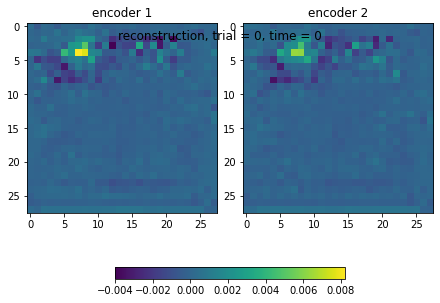

In [37]:
fig, axs = plt.subplots(1, 2, constrained_layout=True)
arrs = [X0_back1, X0_back2]
vmin = min(np.min(a) for a in arrs); vmax = max(np.max(a) for a in arrs)
im = axs[0].imshow(X0_back1, vmin=vmin, vmax=vmax); axs[0].set_title('encoder 1')
axs[1].imshow(X0_back2, vmin=vmin, vmax=vmax);       axs[1].set_title('encoder 2')
# axs[2].imshow(X0_back3, vmin=vmin, vmax=vmax);       axs[2].set_title('encoder 3')
# axs[3].imshow(X0_back4, vmin=vmin, vmax=vmax);       axs[3].set_title('encoder 4')
fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.06, pad=0.18)
fig.suptitle(f"reconstruction, trial = {trial_check}, time = {T_check}", y=0.96)
plt.show()

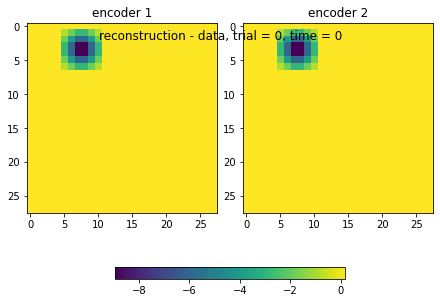

In [38]:
X1_ori = dset_samples[trial_check][T_check,0,:,:]
fig, axs = plt.subplots(1, 2, constrained_layout=True)
arrs = [X0_back1 , X0_back2] - X1_ori
vmin = min(np.min(a) for a in arrs); vmax = max(np.max(a) for a in arrs)
im = axs[0].imshow(X0_back1 - X1_ori, vmin=vmin, vmax=vmax);  axs[0].set_title('encoder 1')
axs[1].imshow(X0_back2 - X1_ori, vmin=vmin, vmax=vmax);       axs[1].set_title('encoder 2')
# axs[2].imshow(X0_back3 - X1_ori, vmin=vmin, vmax=vmax);       axs[2].set_title('encoder 3')
# axs[3].imshow(X0_back4 - X1_ori, vmin=vmin, vmax=vmax);       axs[3].set_title('encoder 4')
fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.06, pad=0.18)
fig.suptitle(f"reconstruction - data, trial = {trial_check}, time = {T_check}", y=0.96)
plt.show()

# 3. Simulate Trajectories

In [39]:
n_step = T_max

## 3.1 Data space (tau = 1.0)

In [75]:
tau = 1.0
traj_sim_tau1_flattent, lag_cov_list1 = generate_traj_image_onthefly(dyn_net1.to(device),
                                                                    dset_samples, n_step,
                                                                    tau, device, lag,
                                                                    include_x0_tau=False,
                                                                    oracle=False, lag_cov_list_pre=None,
                                                                    flow_net=None,
                                                                    clamp_range=clamp_range
                                                                    )

100%|██████████| 47/47 [00:05<00:00,  8.07it/s]


In [65]:
out_imgs_tau11 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau1_flattent]

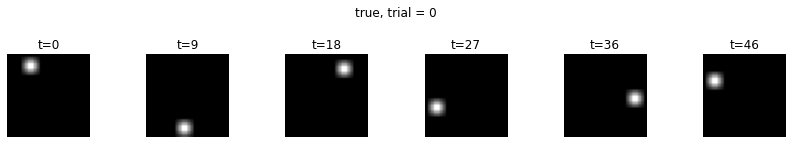

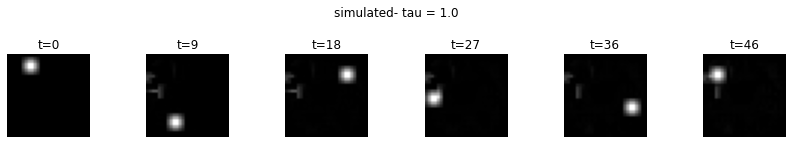

In [66]:
plot_tau(T, out_imgs_tau11, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

In [76]:
tau = 1.0
traj_sim_tau1_flattent, lag_cov_list2 = generate_traj_image_onthefly(dyn_net2.to(device),
                                                                    dset_samples, n_step,
                                                                    tau, device, lag,
                                                                    include_x0_tau=False,
                                                                    oracle=False, lag_cov_list_pre=None,
                                                                    flow_net=None,
                                                                    clamp_range=clamp_range
                                                                    )

100%|██████████| 47/47 [00:05<00:00,  8.46it/s]


In [68]:
out_imgs_tau12 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau1_flattent]

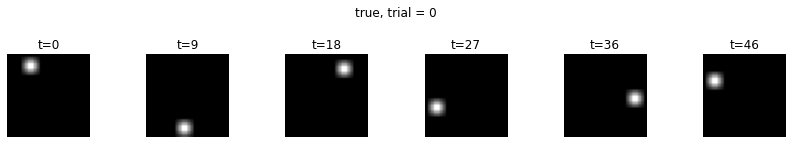

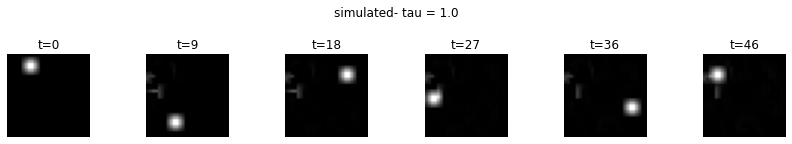

In [69]:
plot_tau(T, out_imgs_tau12, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

## 3.2 Latent space (tau = 0.0)

### 3 versions of obtaining simulated trajectories in tau = 0.0

Now, our dynamic vector field is conditioning on history **in data space (tau = 1.0)**. So, there are 2 versions of rollover:

1. generate data to next $\delta t$ in tau = 0.0 first, and then flow back to tau = 1.0 as history for next step. (**no reuse**)
2. Reuse simulated trajectories from tau = 1.0 as history directly (**reuse**) (This is conceptually wrong, but if it matches to version 1, then it's a strong signal of commutation between 2 flows)

Moreover, we can simply flow the simulated trajectories in tau = 1.0 to tau = 0.0 directly

# PCA initialization

In [82]:
# out_imgs_tau0_flow_flatten = proj_to_latent(out_imgs_tau11, flow_net1.to(device), 0.0, device)
# out_imgs_tau0_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in out_imgs_tau0_flow_flatten ]

In [83]:
# tau = 0.0
# traj_sim_tau0_flattent_reuse, _ = generate_traj_image_onthefly(dyn_net1.to(device),
#                                                          dset_samples, n_step,
#                                                          tau, device, lag,
#                                                          include_x0_tau=False,
#                                                          oracle=False,
#                                                          lag_cov_list_pre=lag_cov_list1,
#                                                          flow_net=flow_net1.to(device),
#                                                          clamp_range=clamp_range, reuse = True
#                                                          )
# out_imgs_tau0_reuse = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent_reuse ]

In [84]:
# tau = 0.0
# traj_sim_tau0_flattent_noReuse, _ = generate_traj_image_onthefly(dyn_net1.to(device),
#                                                          dset_samples, n_step,
#                                                          tau, device, lag,
#                                                          include_x0_tau=False,
#                                                          oracle=False,
#                                                          lag_cov_list_pre=None,
#                                                          flow_net=flow_net1.to(device),
#                                                          clamp_range=clamp_range, reuse = False
#                                                          )
# out_imgs_tau0_noReuse = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent_noReuse ]

In [85]:
# plot_tau(T, out_imgs_tau0_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'porjected, tau = 0.0; flow from tau = 1.0 directly')

In [86]:
# plot_tau(T, out_imgs_tau0_noReuse, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; no reuse, version 1')

In [87]:
# plot_tau(T, out_imgs_tau0_reuse, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; reuse, version 2')

# random initialization

In [46]:
out_imgs_tau0_flow_flatten = proj_to_latent(out_imgs_tau12, flow_net2.to(device), 0.0, device)
out_imgs_tau0_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in out_imgs_tau0_flow_flatten ]

In [48]:
tau = 0.0
traj_sim_tau0_flattent_reuse, _ = generate_traj_image_onthefly(dyn_net2.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         lag_cov_list_pre=lag_cov_list,
                                                         flow_net=flow_net2.to(device),
                                                         clamp_range=clamp_range, reuse = True
                                                         )
out_imgs_tau0_reuse = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent_reuse ]

100%|██████████| 47/47 [00:03<00:00, 13.97it/s]


In [49]:
tau = 0.0
traj_sim_tau0_flattent_noReuse, _ = generate_traj_image_onthefly(dyn_net2.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         lag_cov_list_pre=None,
                                                         flow_net=flow_net2.to(device),
                                                         clamp_range=clamp_range, reuse = False
                                                         )
out_imgs_tau0_noReuse = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent_noReuse ]

100%|██████████| 47/47 [00:10<00:00,  4.51it/s]


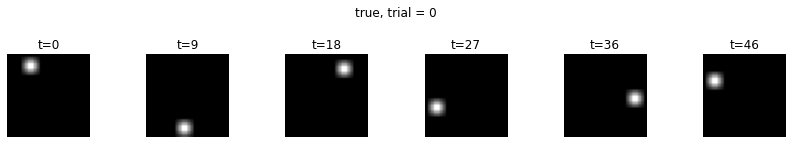

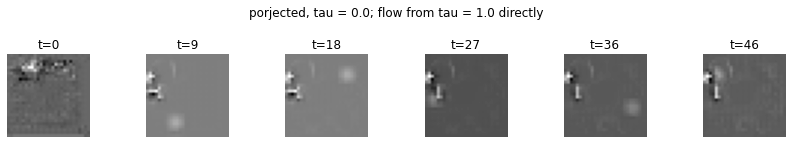

In [50]:
plot_tau(T, out_imgs_tau0_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'porjected, tau = 0.0; flow from tau = 1.0 directly')

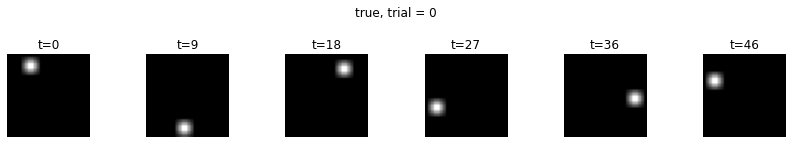

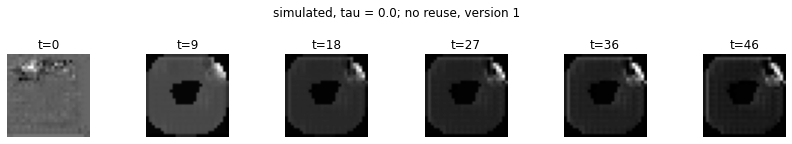

In [51]:
plot_tau(T, out_imgs_tau0_noReuse, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; no reuse, version 1')

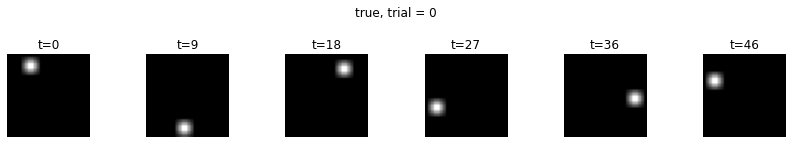

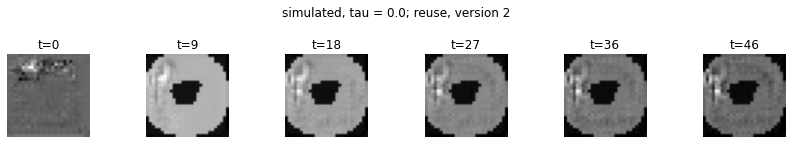

In [52]:
plot_tau(T, out_imgs_tau0_reuse, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; reuse, version 2')

Let's see the differences between flowed and simulated.

In [53]:
# diff_list  =[out_imgs_tau0_flow[ii] - out_imgs_tau0_noReuse[ii] for ii in range(len(out_imgs_tau0_noReuse))]
# fig, axs = plt.subplots(1, 4, constrained_layout=True)
# arrs = [diff_list[0][0,0,:,:] , diff_list[0][10,0,:,:], diff_list[0][20,0,:,:], diff_list[0][30,0,:,:]]
# vmin = min(np.min(a) for a in arrs); vmax = max(np.max(a) for a in arrs)
# im = axs[0].imshow(X0_back1 - X1_ori, vmin=vmin, vmax=vmax);  axs[0].set_title('t=0')
# axs[1].imshow(X0_back2 - X1_ori, vmin=vmin, vmax=vmax);       axs[1].set_title('t=1')
# axs[2].imshow(X0_back3 - X1_ori, vmin=vmin, vmax=vmax);       axs[2].set_title('t=2')
# axs[3].imshow(X0_back4 - X1_ori, vmin=vmin, vmax=vmax);       axs[3].set_title('t=3')
# fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.06, pad=0.18)

# 4. Latent space

In [54]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]

## 4.1 directly from encoder: mu(x_data)

In [55]:
data_flattent[1].shape

(48, 784)

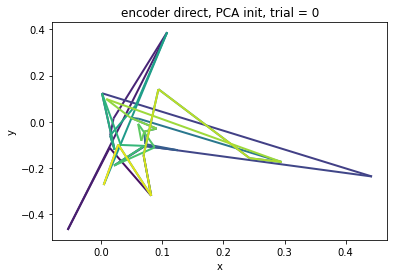

In [56]:
dim_to_keep = 2
fig, axs = plt.subplots()
norm  = Normalize(vmin=0, vmax=T_max)
mu_keep1 = get_mu_from_encoder(encoder1, data_flattent, dim_to_keep, TRIAL_IDX)
plot_latent_2d(axs, mu_keep1, norm, 'encoder direct, PCA init, trial = ' + str(TRIAL_IDX))

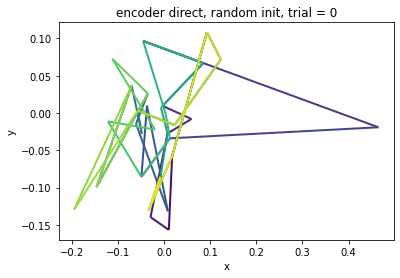

In [57]:
dim_to_keep = 2
fig, axs = plt.subplots()
norm  = Normalize(vmin=0, vmax=T_max)
mu_keep2 = get_mu_from_encoder(encoder2, data_flattent, dim_to_keep, TRIAL_IDX)
plot_latent_2d(axs, mu_keep2, norm, 'encoder direct, random init, trial = ' + str(TRIAL_IDX))

In [58]:
# dim_to_keep = 2
# mu_keep1 = get_mu_from_encoder(encoder1, data_flattent, dim_to_keep, TRIAL_IDX)
# mu_keep2 = get_mu_from_encoder(encoder2, data_flattent, dim_to_keep, TRIAL_IDX)
# # mu_keep3 = get_mu_from_encoder(encoder3, data_flattent, dim_to_keep, TRIAL_IDX)
# # mu_keep4 = get_mu_from_encoder(encoder4, data_flattent, dim_to_keep, TRIAL_IDX)
# xys     = [mu_keep1, mu_keep2, mu_keep3, mu_keep4]
# # titles  = ['recon', 'recon + DIP', 'recon + DIP + Lie', 'recon + DIP + Lie + flow']
# titles  = ['recon', 'recon + DIP', 'recon + DIP + Flow', 'recon + DIP + flow + Lie']
# snap_shot_plot(xys, titles, TRIAL_IDX)

## 4.2 flowed/ project

In [59]:
latent_traj_list1 = proj_to_latent(dset_samples, flow_net1.to(device), 0.0, device)
mu_traj_sim1, d1, L1, loading1 = latent_mu(latent_traj_list1, encoder1.to(device), dim_to_keep, device, fullRes = True)

In [60]:
latent_traj_list2 = proj_to_latent(dset_samples, flow_net2.to(device), 0.0, device)
mu_traj_sim2, d2, L2, loading2 = latent_mu(latent_traj_list2, encoder2.to(device), dim_to_keep, device, fullRes = True)

In [61]:
mu_traj_flow_np1 = [mu_traj_sim1[j].cpu().numpy() for j in range(len(mu_traj_sim1))]
mu_traj_flow_np2 = [mu_traj_sim2[j].cpu().numpy() for j in range(len(mu_traj_sim2))]

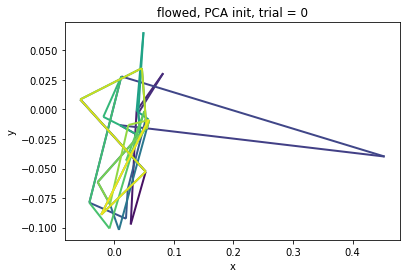

In [62]:
fig, axs = plt.subplots()
norm  = Normalize(vmin=0, vmax=T_max)
plot_latent_2d(axs, mu_traj_flow_np1[TRIAL_IDX], norm, 'flowed, PCA init, trial = ' + str(TRIAL_IDX))

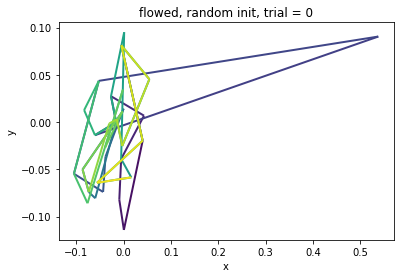

In [63]:
fig, axs = plt.subplots()
norm  = Normalize(vmin=0, vmax=T_max)
plot_latent_2d(axs, mu_traj_flow_np2[TRIAL_IDX], norm, 'flowed, random init, trial = ' + str(TRIAL_IDX))

## 4.3 simulated

In [78]:
# dim_to_keep = 2
# mu_traj_sim1, d1, L1, loading1 = latent_mu(traj_sim_tau0_flattent_noReuse, encoder1.to(device), dim_to_keep, device, fullRes = True)
# mu_traj_sim2, d2, L2, loading2 = latent_mu(traj_sim_tau0_flattent_noReuse, encoder1.to(device), dim_to_keep, device, fullRes = True)

In [168]:
# d[0:10]

tensor([1.7305e-01, 1.1729e-01, 4.8615e-06, 2.3481e-06, 6.6514e-06, 4.8687e-06,
        7.1926e-06, 9.9897e-06, 1.0000e-05, 1.0000e-05], device='cuda:0')

In [ ]:
# idx_show = 100
# plt.imshow(loading[0:idx_show,0:idx_show].detach().cpu().numpy(), cmap = 'gray_r')
# plt.title('loading')
# plt.colorbar()

In [170]:
# mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
# mu_traj_sim_np_plot = [mu_traj_sim_np[ii][10:,:] for ii in range(len(mu_traj_sim_np))]
# plot_latent_time_series(mu_traj_sim_np_plot, alpha = 0.4, dims=np.arange(dim_to_keep), 
#                         dt=0.01, labels=None)
# plt.suptitle('simulated latent trajc for each trial')

In [ ]:
# fig, axs = plt.subplots()
# norm  = Normalize(vmin=0, vmax=T_max)
# plot_latent_2d(axs, mu_traj_sim_np[TRIAL_IDX], norm, 'simulated, trial = ' + str(TRIAL_IDX))

# Appendix: put all plots together

In [172]:
len(dset_samples)

10

In [173]:
TRIAL_IDX =9

In [ ]:
T = T_max
plot_ball_coordinate(TRIAL_IDX, dset_samples, T)

In [ ]:
plot_tau(T, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

In [ ]:
plot_tau(T, out_imgs_tau0_noReuse, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; no reuse, version 1')

In [ ]:
dim_to_keep = 2
mu_keep1 = get_mu_from_encoder(encoder1, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep2 = get_mu_from_encoder(encoder2, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep3 = get_mu_from_encoder(encoder3, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep4 = get_mu_from_encoder(encoder4, data_flattent, dim_to_keep, TRIAL_IDX)
xys     = [mu_keep1, mu_keep2, mu_keep3, mu_keep4]
titles  = ['recon', 'recon + DIP', 'recon + DIP + Flow', 'recon + DIP + flow + Lie']
snap_shot_plot(xys, titles, TRIAL_IDX)

In [ ]:
fig, axs = plt.subplots()
norm  = Normalize(vmin=0, vmax=T_max)
plot_latent_2d(axs, mu_traj_flow_np[TRIAL_IDX], norm, 'flowed, trial = ' + str(TRIAL_IDX))

In [ ]:
fig, axs = plt.subplots()
norm  = Normalize(vmin=0, vmax=T_max)
plot_latent_2d(axs, mu_traj_sim_np[TRIAL_IDX], norm, 'simulated, trial = ' + str(TRIAL_IDX))

In [180]:
TRIAL_IDX =0